In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
colors_choice = ["#5C0A72", "#FD672C"]
colors_aperture = ["#E41A1C", "#437FB5", "#4daf4a", "#984ea3", "#ff7f00"]
colors_multi_aperture = ["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"]
colors_aperture_pale = ["#EC8788", "#96B9D6"]




# import

In [ ]:

import os
import time
import warnings
from datetime import datetime, date
from pathlib import Path

import gymnasium as gym
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gymnasium import spaces
from IPython.display import clear_output
from scipy.special import erfc
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from tqdm import tqdm




BASE_PATH = "/Users/yc/Desktop"

# plot setting ------------------------
# plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

# colors
state_color = 'blue'
belief_color = color=colors_choice[0]
eye_color = 'red'
cmap_eye = mcolors.LinearSegmentedColormap.from_list('eye_cmap', ['white', eye_color])
cmap_state = mcolors.LinearSegmentedColormap.from_list('state_cmap', ['white', state_color])
cmap_belief = mcolors.LinearSegmentedColormap.from_list('belief_cmap', ['white', belief_color])

In [5]:
def style():
    """
    Set the style of the plots.

    This function sets the font color, size and weight, and axis label properties
    for a matplotlib plot using the Google style guidelines.
    """
    font_color = "black"
    font_size = 18
    plt.rcParams.update(
        {
            "text.color": font_color,
            "axes.labelcolor": font_color,
            "axes.labelsize": font_size,
            # "axes.titleweight": "bold",
            "axes.titlesize": font_size,
            "xtick.labelcolor": font_color,
            "xtick.labelsize": font_size,
            "ytick.labelcolor": font_color,
            "ytick.labelsize": font_size,
            "font.weight": "regular",
        }
    )

    plt.rc("axes.spines", top=False, bottom=True, left=True, right=False)
    plt.rc("axes", edgecolor=font_color)


style()

# model

In [6]:

class MouseNavigationEnv(gym.Env):
    """
    Mouse Navigation Environment with Left and Right Visual Areas.

    The mouse navigates a 2D arena to find the correct reward port based on
    accumulated left and right visual information, affected by observation noise.
    """

    def __init__(self, noise, info_matrix, nx=60, ny=50, max_v=4, i_threshold=20,
                 vcost=0.01, wcost=0.01, timecost=0.01, info_scale=1 / 20,
                 max_steps=100, reward_magnitude=1):
        super(MouseNavigationEnv, self).__init__()

        # Arena dimensions
        self.nx = nx
        self.ny = ny
        self.max_v = max_v
        self.i_threshold = i_threshold

        # Observation noise (standard deviation)
        self.noise = noise

        # Costs
        self.vcost = vcost
        self.wcost = wcost
        self.timecost = timecost
        self.info_scale = info_scale
        self.reward_magnitude = reward_magnitude

        self.info_matrix = info_matrix

        # Port locations
        self.left_port_x = 0
        self.right_port_x = nx - 1
        self.port_y = ny - 1

        # Correct port will be randomly selected in reset()
        self.correct_port_x = None

        # Maximum steps per episode
        self.max_steps = max_steps

        # Action space: Acceleration in x and y directions [-3, -2, -1, 0, 1, 2, 3]
        self.action_space = spaces.MultiDiscrete([7, 7])

        # Observation space: [x, y, vx, vy, left_info, right_info]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, -1, -1, -1]),
            high=np.array([1, 1, 1, 1, 1]), # normalize
            # high=np.array([nx - 1, ny - 1, max_v, max_v, 1]),
            dtype=np.float32
        )

        # Initialize state
        self.reset()

    def reset(self, seed=None, options=None, x=None, y=None):
        """Reset the environment to the starting state."""
        super().reset(seed=seed)

        # Start at the bottom center
        if x is None and y is None:
            self.x = self.nx // 2
            self.y = 0

            # Start with zero velocity
            self.vx = 0
            self.vy = 0
        else:
            self.x = x
            self.y = y

        # Reset accumulated information
        self.cumulative_info = 0

        # Reset step counter
        self.steps = 0

        if options is not None:
            self.correct_port_x = options
        else:
            # Randomly select the correct port (left or right)
            self.correct_port_x = np.random.choice([self.left_port_x, self.right_port_x])

        # Current state
        self._update_state()

        return self.state, {}

    def _update_state(self):
        """Update the state vector."""
        if self.correct_port_x == 0:
            rewardp=self._success_prob_from_info(self.cumulative_info)*2-1
        else:
            rewardp=(self._success_prob_from_info(-self.cumulative_info)*2-1)*-1
        self.state = np.array([
            self.x/(self.nx-1), 
            self.y/(self.ny-1), 
            self.vx/self.max_v, 
            self.vy/self.max_v,
            rewardp
        ], dtype=np.float32)

    def _get_area_info_at_position(self, x, y, testing=False):
        """Get left and right area information at the given position with noise."""
        # Convert to integer indices and clip to bounds
        x_idx = max(0, min(int(x), self.nx - 1))
        y_idx = max(0, min(int(y), self.ny - 1))

        # Get raw values from matrices
        raw = self.info_matrix[x_idx, y_idx] * self.info_scale

        # Add observation noise. the noisy can be no info at all, or can by no noise (full info at the location)
        # we want: less info more chance to not observe anyything
        # noisy = (raw - np.max(self.info_matrix)/3*self.noise*(np.random.uniform(0, 1)))
        p=raw/np.max(self.info_matrix)
        noisy=(p-np.random.uniform(0, 1*self.noise))
        noisy = max(0, noisy)

        if testing:
            noisy = raw
        if self.correct_port_x == 0:
            return noisy
        else:
            return -noisy

    def _success_prob_from_info(self, info_val):
        """
        Calculate success probability based on accumulated left and right information.
        Higher difference between the correct choice and incorrect choice
        leads to higher success probability.
        """

        info_val = abs(info_val)

        # Use the erfc function: (1/2) * erfc(-sqrt(J/2))
        return 0.5 * erfc(-np.sqrt(info_val / 2))

    def step(self, action, testing=False):
        """
        Take a step in the environment based on the action.

        Args:
            action: [ax, ay] representing accelerations in x and y directions
                   Each element is in range [0, 6] which maps to [-3, -2, -1, 0, 1, 2, 3]

        Returns:
            (state, reward, done, truncated, info)
        """
        # Increment step counter
        self.steps += 1

        # Map action to acceleration
        ax = action[0]-3
        ay = action[1]-3
        # print(ax,ay)
        # Calculate next velocity
        next_vx = self.vx + ax
        next_vy = self.vy + ay
        # print(next_vx,next_vy)
        # Check velocity constraints
        speed = np.sqrt(next_vx**2 + next_vy**2)
        if speed >= self.max_v:
            # Scale down the velocity to max_v
            scaling_factor = (self.max_v - 0.1) / speed
            next_vx = next_vx * scaling_factor
            next_vy = next_vy * scaling_factor

        # Store old position for reward calculation
        old_x, old_y = self.x, self.y

        # Update position
        self.x += next_vx
        self.y += next_vy

        # Clip position to arena boundaries
        self.x = max(0, min(self.x, self.nx - 1))
        self.y = max(0, min(self.y, self.ny - 1))

        # Check if approaching a port and enforce horizontal approach
        approaching_port = (self.y >= self.port_y - abs(next_vy) and
                            (abs(self.x - self.left_port_x) <= abs(next_vx) or
                            abs(self.x - self.right_port_x) <= abs(next_vx)))

        if approaching_port:
            # Force horizontal approach by zeroing out vertical velocity
            self.vy = 0
        else:
            self.vy = next_vy

        self.vx = next_vx

        # Accumulate left and right information at current position
        info_gain = self._get_area_info_at_position(old_x, old_y, testing)
        self.cumulative_info += info_gain

        # Calculate costs
        velocity_cost = np.sqrt(self.vx**2 + self.vy**2) * self.vcost
        accel_cost = np.sqrt(ax**2 + ay**2) * self.wcost
        step_cost = -velocity_cost - accel_cost - self.timecost

        # Check if done
        at_left_port = (round(self.y) == self.port_y and round(self.x) == self.left_port_x)
        at_right_port = (round(self.y) == self.port_y and round(self.x) == self.right_port_x)
        at_port = at_left_port or at_right_port

        stopped = (abs(self.vx) < 0.01 and abs(self.vy) < 0.01 and self.steps > 1)
        reached_steps_limit = self.steps >= self.max_steps

        done = at_port or stopped or reached_steps_limit

        # Calculate reward
        reward = step_cost  # Always apply movement costs
        success_prob = self._success_prob_from_info(self.cumulative_info)
        if at_port:
            # Calculate success probability based on accumulated information
            

            # Check if the mouse chose the correct port
            correct_choice = ((at_left_port and self.correct_port_x == self.left_port_x) or
                              (at_right_port and self.correct_port_x == self.right_port_x))

            # Stochastically determine success based on accumulated information
            if correct_choice:
                # Success with probability based on accumulated info
                reward_outcome = success_prob * self.reward_magnitude
            else:
                # Failure with probability based on accumulated info (incorrect choice)
                # reward_outcome = 1 - success_prob*self.reward_magnitude
                reward_outcome = -success_prob * self.reward_magnitude*5

            reward += reward_outcome
        elif stopped:
            # Penalty for stopping without reaching a port
            reward -= 0.5 * self.reward_magnitude
        elif reached_steps_limit:
            # Small penalty for timeout
            reward -= 0.25 * self.reward_magnitude

        # if know which port, reward for going toward it
        # if success_prob>0.3:
        #     # print(success_prob, self.vx, np.sign(self.cumulative_info), success_prob*self.vx*np.sign(self.cumulative_info)*-1)
        #     away_punish=success_prob*self.vx*np.sign(self.cumulative_info)*-1*0.05
        #     reward+=min(0,away_punish)

        # Update state
        self._update_state()

        # Info dictionary for additional data
        info = {
            'position': (self.x, self.y),
            'velocity': (self.vx, self.vy),
            'cumulative_info': self.cumulative_info,
            'step_cost': step_cost,
            'at_port': at_port,
            'correct_port': 'left' if self.correct_port_x == self.left_port_x else 'right',
            'chosen_port': 'left' if at_left_port else ('right' if at_right_port else None),
            'success_prob': self._success_prob_from_info(
                self.cumulative_info
            ),
            'info_gain': info_gain,
        }

        return self.state, reward, done, False, info



# overhead background

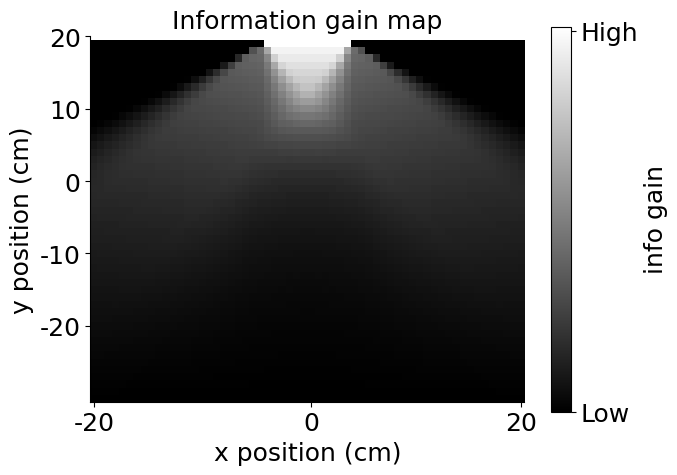

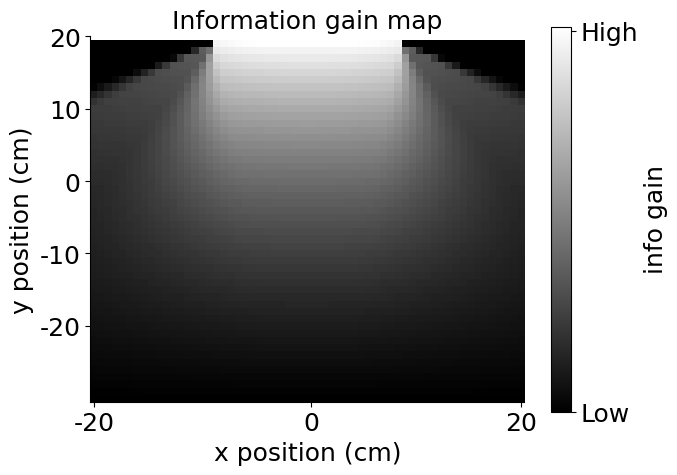

In [19]:
for gap_width in [6, 13]:
    port_reward = 1
    info_matrix = np.load(f'new_info_matrix_hres_{gap_width}.npy')[:, :-10]

    # Create vertical mask gradient
    mask = np.ones_like(info_matrix)
    gradient = np.linspace(0.0, 1., info_matrix.shape[1])
    for i in range(info_matrix.shape[1]):
        mask[:, i] = gradient[i]
    masked_info_matrix = info_matrix * mask

    # Plot info map
    plt.figure(figsize=(7, 5))
    c = plt.imshow(masked_info_matrix.T, origin='lower', cmap='gray')

    # Colorbar
    cbar = plt.colorbar(c, label='info gain')
    cbar.set_ticks([0, 20])
    cbar.set_ticklabels(['Low', 'High'])

    # Match axis style from trajectory plot
    plt.xlabel('x position (cm)')
    plt.ylabel('y position (cm)')
    plt.xticks([0, 30, 59], ['-20', '0', '20'])
    plt.yticks([10, 20, 30, 40, 50], ['-20', '-10', '0', '10', '20'])

    plt.title('Information gain map')

    plt.savefig(f"aperture_{gap_width}_infomap.svg", format="svg", bbox_inches='tight')
    plt.show()


# overhead trajectory plots
plot raw trajectories, mixed of low and high width.

Model laoded with ./mouse_navigation_modelw6


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Model laoded with ./mouse_navigation_modelw13


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


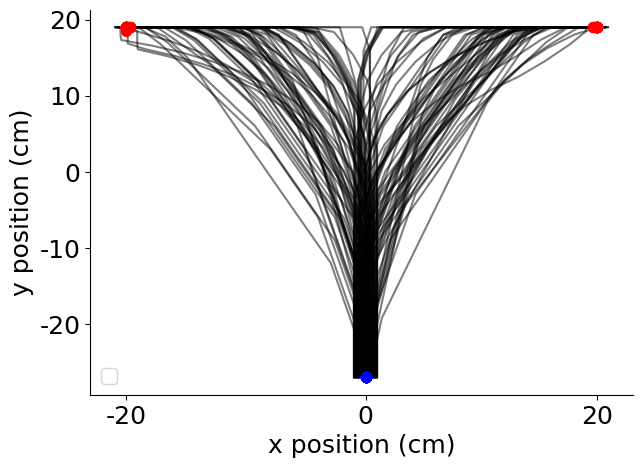

In [7]:
trials_per_condition=30
plt.figure(figsize=(7, 5))

for gap_width in [6,13]:

    port_reward=1
    info_matrix=np.load(f'new_info_matrix_hres_{gap_width}.npy')[:,:-10]
    mask = np.ones_like(info_matrix)
    gradient = np.linspace(0.0, 1., info_matrix.shape[1])
    for i in range(info_matrix.shape[1]):
        mask[:, i] = gradient[i]
    # Apply the mask to darken the bottom gradually
    masked_info_matrix = info_matrix * mask
    # plt.xlabel('world x')
    # plt.ylabel('world y')
    # plt.title('Information gain map')
    # # c= plt.imshow(masked_info_matrix.T,origin='lower', cmap='grey')
    # cbar=plt.colorbar(c, label='info gain')
    # cbar.set_ticks([0, 20])
    # cbar.set_ticklabels(['Low', 'High'])
    # plt.xticks([0,59],['left','right'])
    # plt.yticks([0,49],['backward','forward'])
    # # plt.savefig(f"aperture_{gap_width}_infomap.pdf", format="pdf", bbox_inches="tight")
    # # plt.show()

    # Create environment
    env = MouseNavigationEnv(
        info_matrix=info_matrix,
        nx=60, ny=50, max_v=4, i_threshold=5, 
        noise=0.3, 
        vcost=0.01, 
        wcost=0.01, 
        timecost=0.001, 
        info_scale=0.3,
        max_steps=200, 
        reward_magnitude=3
    )

    model_path = f"./mouse_navigation_modelw{gap_width}"
    print(f"Model laoded with {model_path}")
    model = PPO.load(model_path)  # Replace PPO with your algorithm


    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        
        # Create lists to store trajectories for multiple trials
        left_trial_positions_x = []
        left_trial_positions_y = []
        left_trial_info_values = []
        left_trial_results = []
        left_trial_rewards = []
        left_trial_final_info = []
        
        right_trial_positions_x = []
        right_trial_positions_y = []
        right_trial_info_values = []
        right_trial_results = []
        right_trial_rewards = []
        right_trial_final_info = []
        
        # Run multiple left port trials
        for trial in range(trials_per_condition):
            # Reset environment for left port trial
            # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  # +6 because upper bound is exclusive
            # y = np.random.randint(0, 2)  # centered around 0, so y ∈ [-5, 5]
            # obs, _ = env.reset(options=0, x=x, y=y)
            obs, _ = env.reset(options=0)
            # print(f"Left trial {trial+1}, correct port: {env.correct_port_x}")
            done = False

            # Track positions for this trial
            positions_x = []
            positions_y = []
            info_values = []
            total_reward = 0

            # Run the left trial
            while not done:
                # Get action from model
                action, _ = model.predict(obs, deterministic=True)

                # Execute action
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                # print(env.state, reward)
                
                # Track position and information
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
                info_values.append(info['cumulative_info'])
            
            # Convert to numpy arrays
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            # Store this trial's data
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
            left_trial_info_values.append(info_values)
            left_trial_rewards.append(total_reward)
            left_trial_final_info.append(info)
            
            # Determine result
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            left_trial_results.append(result)
        
        # Run multiple right port trials
        for trial in range(trials_per_condition):
            # Reset environment for right port trial
            # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  
            # y = np.random.randint(0, 2) 
            # obs, _ = env.reset(options=59, x=x, y=y)
            obs, _ = env.reset(options=59)
            # print(f"Right trial {trial+1}, correct port: {env.correct_port_x}")
            done = False

            # Track positions for this trial
            positions_x = []
            positions_y = []
            info_values = []
            total_reward = 0

            # Run the right trial
            while not done:
                # Get action from model
                action, _ = model.predict(obs, deterministic=True)

                # Execute action
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                # print(env.state, reward)
                
                # Track position and information
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
                info_values.append(info['cumulative_info'])
            
            # Convert to numpy arrays
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            # Store this trial's data
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
            right_trial_info_values.append(info_values)
            right_trial_rewards.append(total_reward)
            right_trial_final_info.append(info)
            
            # Determine result
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            right_trial_results.append(result)


        # Plot all left port trial trajectories
        for i, (positions_x, positions_y) in enumerate(zip(left_trial_positions_x, left_trial_positions_y)):
            # Offset each trial slightly for better visualization
            offset = 0.1 * (i - (trials_per_condition-1)/2)
            plt.plot(positions_x + offset, positions_y, 'k', alpha=0.5, linewidth=1.5, markersize=3)
            plt.scatter(positions_x[0], positions_y[0], color='blue', s=50, marker='o',zorder=10)
            plt.scatter(positions_x[-1], positions_y[-1], color='red', s=50, marker='o',zorder=10)

        # Plot all right port trial trajectories
        for i, (positions_x, positions_y) in enumerate(zip(right_trial_positions_x, right_trial_positions_y)):
            # Offset each trial slightly for better visualization
            offset = 0.1 * (i - (trials_per_condition-1)/2)
            plt.plot(positions_x + offset, positions_y, 'k', alpha=0.5, linewidth=1.5, markersize=3)
            plt.scatter(positions_x[0], positions_y[0], color='blue', s=50, marker='o',zorder=10)
            plt.scatter(positions_x[-1], positions_y[-1], color='red', s=50, marker='o',zorder=10)

        # Plot ports
        # plt.scatter(env.left_port_x, env.port_y, color='red', s=100, marker='s', label='Left port')
        # plt.scatter(env.right_port_x, env.port_y, color='green', s=100, marker='s', label='Right port')
        # plt.scatter(env.correct_port_x, env.port_y, color='yellow', s=150, marker='*', label='Correct port')

        plt.xlabel('x position (cm)')
        plt.ylabel('y position (cm)')
        plt.legend()
        # plt.grid(alpha=0.3)

        plt.xticks([-0,30,59],['-20','0','20'])
        plt.yticks( [10,20, 30, 40, 50], [-20,-10,0,10,20] )



plt.savefig("overhead all raw.svg", format='svg', bbox_inches='tight')
# plt.show()



# overhead trajectory plots
plot raw trajectories, seperate low and high width.

Model laoded with ./mouse_navigation_modelw6


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


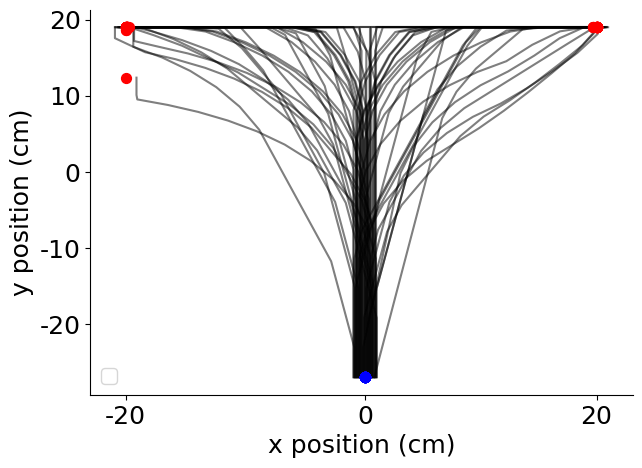

Model laoded with ./mouse_navigation_modelw13


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


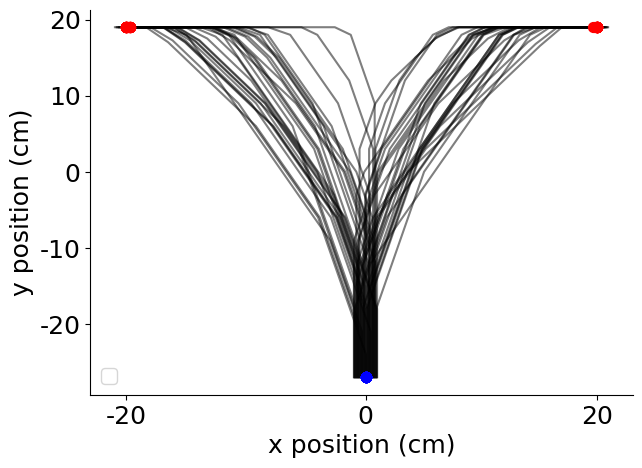

In [8]:
trials_per_condition=30

for gap_width in [6,13]:

    port_reward=1
    info_matrix=np.load(f'new_info_matrix_hres_{gap_width}.npy')[:,:-10]
    mask = np.ones_like(info_matrix)
    gradient = np.linspace(0.0, 1., info_matrix.shape[1])
    for i in range(info_matrix.shape[1]):
        mask[:, i] = gradient[i]
    # Apply the mask to darken the bottom gradually
    masked_info_matrix = info_matrix * mask


    # Create environment
    env = MouseNavigationEnv(
        info_matrix=info_matrix,
        nx=60, ny=50, max_v=4, i_threshold=5, 
        noise=0.3, 
        vcost=0.01, 
        wcost=0.01, 
        timecost=0.001, 
        info_scale=0.3,
        max_steps=200, 
        reward_magnitude=3
    )

    model_path = f"./mouse_navigation_modelw{gap_width}"
    print(f"Model laoded with {model_path}")
    model = PPO.load(model_path)  # Replace PPO with your algorithm

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

    
        # Create lists to store trajectories for multiple trials
        left_trial_positions_x = []
        left_trial_positions_y = []
        left_trial_info_values = []
        left_trial_results = []
        left_trial_rewards = []
        left_trial_final_info = []
        
        right_trial_positions_x = []
        right_trial_positions_y = []
        right_trial_info_values = []
        right_trial_results = []
        right_trial_rewards = []
        right_trial_final_info = []
        
        # Run multiple left port trials
        for trial in range(trials_per_condition):
            # Reset environment for left port trial
            # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  # +6 because upper bound is exclusive
            # y = np.random.randint(0, 2)  # centered around 0, so y ∈ [-5, 5]
            # obs, _ = env.reset(options=0, x=x, y=y)
            obs, _ = env.reset(options=0)
            # print(f"Left trial {trial+1}, correct port: {env.correct_port_x}")
            done = False

            # Track positions for this trial
            positions_x = []
            positions_y = []
            info_values = []
            total_reward = 0

            # Run the left trial
            while not done:
                # Get action from model
                action, _ = model.predict(obs, deterministic=True)

                # Execute action
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                # print(env.state, reward)
                
                # Track position and information
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
                info_values.append(info['cumulative_info'])
            
            # Convert to numpy arrays
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            # Store this trial's data
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
            left_trial_info_values.append(info_values)
            left_trial_rewards.append(total_reward)
            left_trial_final_info.append(info)
            
            # Determine result
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            left_trial_results.append(result)
        
        # Run multiple right port trials
        for trial in range(trials_per_condition):
            # Reset environment for right port trial
            # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  
            # y = np.random.randint(0, 2) 
            # obs, _ = env.reset(options=59, x=x, y=y)
            obs, _ = env.reset(options=59)
            # print(f"Right trial {trial+1}, correct port: {env.correct_port_x}")
            done = False

            # Track positions for this trial
            positions_x = []
            positions_y = []
            info_values = []
            total_reward = 0

            # Run the right trial
            while not done:
                # Get action from model
                action, _ = model.predict(obs, deterministic=True)

                # Execute action
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                # print(env.state, reward)
                
                # Track position and information
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
                info_values.append(info['cumulative_info'])
            
            # Convert to numpy arrays
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            # Store this trial's data
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
            right_trial_info_values.append(info_values)
            right_trial_rewards.append(total_reward)
            right_trial_final_info.append(info)
            
            # Determine result
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            right_trial_results.append(result)

        # Create first figure for trajectories
        plt.figure(figsize=(7, 5))
        # c=plt.imshow(info_matrix.T, origin='lower',cmap='grey')
        # cbar=plt.colorbar(c, label='info gain')
        # cbar.set_ticks([0, 20])
        # cbar.set_ticklabels(['Low', 'High'])

        # Plot all left port trial trajectories
        for i, (positions_x, positions_y) in enumerate(zip(left_trial_positions_x, left_trial_positions_y)):
            # Offset each trial slightly for better visualization
            offset = 0.1 * (i - (trials_per_condition-1)/2)
            plt.plot(positions_x + offset, positions_y, 'k', alpha=0.5, linewidth=1.5, markersize=3)
            plt.scatter(positions_x[0], positions_y[0], color='blue', s=50, marker='o',zorder=10)
            plt.scatter(positions_x[-1], positions_y[-1], color='red', s=50, marker='o',zorder=10)

        # Plot all right port trial trajectories
        for i, (positions_x, positions_y) in enumerate(zip(right_trial_positions_x, right_trial_positions_y)):
            # Offset each trial slightly for better visualization
            offset = 0.1 * (i - (trials_per_condition-1)/2)
            plt.plot(positions_x + offset, positions_y, 'k', alpha=0.5, linewidth=1.5, markersize=3)
            plt.scatter(positions_x[0], positions_y[0], color='blue', s=50, marker='o',zorder=10)
            plt.scatter(positions_x[-1], positions_y[-1], color='red', s=50, marker='o',zorder=10)

        # Plot ports
        # plt.scatter(env.left_port_x, env.port_y, color='red', s=100, marker='s', label='Left port')
        # plt.scatter(env.right_port_x, env.port_y, color='green', s=100, marker='s', label='Right port')
        # plt.scatter(env.correct_port_x, env.port_y, color='yellow', s=150, marker='*', label='Correct port')

        plt.xlabel('x position (cm)')
        plt.ylabel('y position (cm)')
        plt.legend()
        # plt.grid(alpha=0.3)

        plt.xticks([-0,30,59],['-20','0','20'])
        plt.yticks( [10,20, 30, 40, 50], [-20,-10,0,10,20] )
        plt.savefig(f"overhead raw gap={gap_width}.svg", format='svg', bbox_inches='tight')

        plt.show()



# overhead average trajectory plots


In [9]:
from scipy.interpolate import interp1d

def interpolate_trajectory(x, y, n_points=100):
    """Interpolate trajectory to fixed number of points"""
    # Calculate cumulative distance along trajectory
    distances = np.cumsum(np.sqrt(np.diff(x)**2 + np.diff(y)**2))
    distances = np.insert(distances, 0, 0)  # Add 0 at start
    
    # Create interpolation functions
    fx = interp1d(distances, x, kind='linear')
    fy = interp1d(distances, y, kind='linear')
    
    # Interpolate to common distance grid
    common_distances = np.linspace(0, distances[-1], n_points)
    new_x = fx(common_distances)
    new_y = fy(common_distances)
    
    return new_x, new_y

# Interpolate all trajectories
n_points = 100
left_interp_x, left_interp_y = [], []

for x, y in zip(left_trial_positions_x, left_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, n_points)
    left_interp_x.append(interp_x)
    left_interp_y.append(interp_y)

# Convert to arrays and compute statistics
left_x_array = np.array(left_interp_x)
left_y_array = np.array(left_interp_y)

left_mean_x = np.mean(left_x_array, axis=0)
left_std_x = np.std(left_x_array, axis=0)
left_mean_y = np.mean(left_y_array, axis=0)
left_std_y = np.std(left_y_array, axis=0)

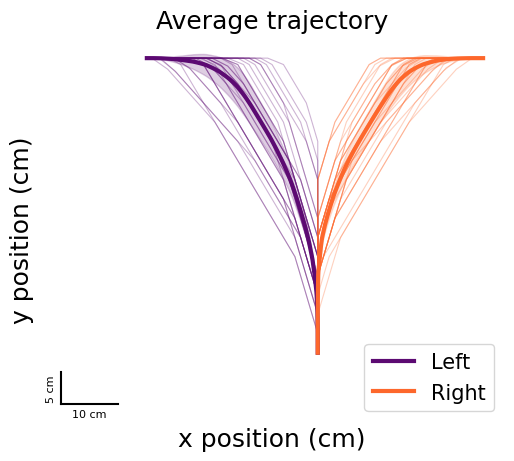

In [13]:
from scipy.interpolate import interp1d

def interpolate_trajectory(x, y, n_points=100):
    """Interpolate trajectory to fixed number of points based on path length"""
    if len(x) < 2:
        x = np.array([x[0], x[0]])
        y = np.array([y[0], y[0]])
    
    distances = np.cumsum(np.sqrt(np.diff(x)**2 + np.diff(y)**2))
    distances = np.insert(distances, 0, 0)
    
    if distances[-1] == 0:
        distances = np.linspace(0, 0.001, len(distances))
    
    fx = interp1d(distances, x, kind='linear', bounds_error=False, fill_value='extrapolate')
    fy = interp1d(distances, y, kind='linear', bounds_error=False, fill_value='extrapolate')
    
    common_distances = np.linspace(0, distances[-1], n_points)
    new_x = fx(common_distances)
    new_y = fy(common_distances)
    
    return new_x, new_y


fig, ax = plt.subplots(figsize=(6, 5))
# Interpolate left trials
left_interp_x, left_interp_y = [], []
for x, y in zip(left_trial_positions_x, left_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, 100)
    left_interp_x.append(interp_x)
    left_interp_y.append(interp_y)

# Interpolate right trials  
right_interp_x, right_interp_y = [], []
for x, y in zip(right_trial_positions_x, right_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, 100)
    right_interp_x.append(interp_x)
    right_interp_y.append(interp_y)

# Process left trials
left_x_array = np.array(left_interp_x)
left_y_array = np.array(left_interp_y)
left_mean_x = np.mean(left_x_array, axis=0)
left_std_x = np.std(left_x_array, axis=0)
left_mean_y = np.mean(left_y_array, axis=0)
left_std_y = np.std(left_y_array, axis=0)

# Process right trials
right_x_array = np.array(right_interp_x)
right_y_array = np.array(right_interp_y)
right_mean_x = np.mean(right_x_array, axis=0)
right_std_x = np.std(right_x_array, axis=0)
right_mean_y = np.mean(right_y_array, axis=0)
right_std_y = np.std(right_y_array, axis=0)

# Plot individual trajectories (lighter)
for positions_x, positions_y in zip(left_trial_positions_x, left_trial_positions_y):
    plt.plot(positions_x, positions_y, color=colors_choice[0], alpha=0.3, linewidth=0.8)

for positions_x, positions_y in zip(right_trial_positions_x, right_trial_positions_y):
    plt.plot(positions_x, positions_y, color=colors_choice[1], alpha=0.3, linewidth=0.8)

# Plot mean trajectories
plt.plot(left_mean_x, left_mean_y, color=colors_choice[0], linewidth=3, label='Left')
plt.plot(right_mean_x, right_mean_y, color=colors_choice[1], linewidth=3, label='Right')

# Add error bands (1 std)
plt.fill_between(left_mean_x, 
                left_mean_y - left_std_y, 
                left_mean_y + left_std_y, 
                alpha=0.2, color=colors_choice[0])
plt.fill_between(right_mean_x, 
                right_mean_y - right_std_y, 
                right_mean_y + right_std_y, 
                alpha=0.2, color=colors_choice[1])


plt.xlabel('x position (cm)')
plt.ylabel('y position (cm)')
plt.legend()
# plt.xticks([0, 30, 59], ['-20', '0', '20'])
# plt.yticks([10, 20, 30, 40, 50], ['-20', '-10', '0', '10', '20'])
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks([])
plt.yticks([])
x0, y0 = -15, -5  # position of origin of scale bar
ax.plot([x0, x0 + 10], [y0, y0], color='black', lw=1.5)  # horizontal bar (10 cm)
ax.plot([x0, x0], [y0, y0 + 5], color='black', lw=1.5)   # vertical bar (5 cm)

# Add text labels
ax.text(x0 + 5, y0 - 0.8, '10 cm', ha='center', va='top', fontsize=8)
ax.text(x0 - 0.8, y0 + 2.5, '5 cm', ha='right', va='center', fontsize=8, rotation='vertical')

ax.set_title('Average trajectory')
plt.show()

# overhead average trajectory plots
seperate by narrow and wide, on same plot

Model laoded with ./mouse_navigation_modelw6
Model laoded with ./mouse_navigation_modelw13


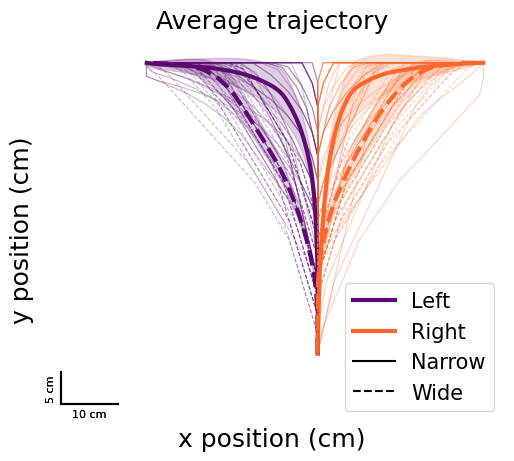

In [14]:
trials_per_condition=30
fig, ax = plt.subplots(figsize=(6, 5))


# plot narrow 
gap_width=6

port_reward=1
info_matrix=np.load(f'new_info_matrix_hres_{gap_width}.npy')[:,:-10]
mask = np.ones_like(info_matrix)
gradient = np.linspace(0.0, 1., info_matrix.shape[1])
for i in range(info_matrix.shape[1]):
    mask[:, i] = gradient[i]
# Apply the mask to darken the bottom gradually
masked_info_matrix = info_matrix * mask

# Create environment
env = MouseNavigationEnv(
    info_matrix=info_matrix,
    nx=60, ny=50, max_v=4, i_threshold=5, 
    noise=0.3, 
    vcost=0.01, 
    wcost=0.01, 
    timecost=0.001, 
    info_scale=0.3,
    max_steps=200, 
    reward_magnitude=3
)

model_path = f"./mouse_navigation_modelw{gap_width}"
print(f"Model laoded with {model_path}")
model = PPO.load(model_path)  # Replace PPO with your algorithm

with warnings.catch_warnings():
    warnings.simplefilter("ignore")


    # Create lists to store trajectories for multiple trials
    left_trial_positions_x = []
    left_trial_positions_y = []
    left_trial_info_values = []
    left_trial_results = []
    left_trial_rewards = []
    left_trial_final_info = []
    
    right_trial_positions_x = []
    right_trial_positions_y = []
    right_trial_info_values = []
    right_trial_results = []
    right_trial_rewards = []
    right_trial_final_info = []
    
    # Run multiple left port trials
    for trial in range(trials_per_condition):
        # Reset environment for left port trial
        # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  # +6 because upper bound is exclusive
        # y = np.random.randint(0, 2)  # centered around 0, so y ∈ [-5, 5]
        # obs, _ = env.reset(options=0, x=x, y=y)
        obs, _ = env.reset(options=0)
        # print(f"Left trial {trial+1}, correct port: {env.correct_port_x}")
        done = False

        # Track positions for this trial
        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        # Run the left trial
        while not done:
            # Get action from model
            action, _ = model.predict(obs, deterministic=True)

            # Execute action
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            # print(env.state, reward)
            
            # Track position and information
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        # Convert to numpy arrays
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        # Store this trial's data
        left_trial_positions_x.append(positions_x)
        left_trial_positions_y.append(positions_y)
        left_trial_info_values.append(info_values)
        left_trial_rewards.append(total_reward)
        left_trial_final_info.append(info)
        
        # Determine result
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        left_trial_results.append(result)
    
    # Run multiple right port trials
    for trial in range(trials_per_condition):
        # Reset environment for right port trial
        # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  
        # y = np.random.randint(0, 2) 
        # obs, _ = env.reset(options=59, x=x, y=y)
        obs, _ = env.reset(options=59)
        # print(f"Right trial {trial+1}, correct port: {env.correct_port_x}")
        done = False

        # Track positions for this trial
        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        # Run the right trial
        while not done:
            # Get action from model
            action, _ = model.predict(obs, deterministic=True)

            # Execute action
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            # print(env.state, reward)
            
            # Track position and information
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        # Convert to numpy arrays
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        # Store this trial's data
        right_trial_positions_x.append(positions_x)
        right_trial_positions_y.append(positions_y)
        right_trial_info_values.append(info_values)
        right_trial_rewards.append(total_reward)
        right_trial_final_info.append(info)
        
        # Determine result
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        right_trial_results.append(result)



# Interpolate left trials
left_interp_x, left_interp_y = [], []
for x, y in zip(left_trial_positions_x, left_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, 100)
    left_interp_x.append(interp_x)
    left_interp_y.append(interp_y)

# Interpolate right trials  
right_interp_x, right_interp_y = [], []
for x, y in zip(right_trial_positions_x, right_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, 100)
    right_interp_x.append(interp_x)
    right_interp_y.append(interp_y)

# Process left trials
left_x_array = np.array(left_interp_x)
left_y_array = np.array(left_interp_y)
left_mean_x = np.mean(left_x_array, axis=0)
left_std_x = np.std(left_x_array, axis=0)
left_mean_y = np.mean(left_y_array, axis=0)
left_std_y = np.std(left_y_array, axis=0)

# Process right trials
right_x_array = np.array(right_interp_x)
right_y_array = np.array(right_interp_y)
right_mean_x = np.mean(right_x_array, axis=0)
right_std_x = np.std(right_x_array, axis=0)
right_mean_y = np.mean(right_y_array, axis=0)
right_std_y = np.std(right_y_array, axis=0)

# Plot individual trajectories (lighter)
for positions_x, positions_y in zip(left_trial_positions_x, left_trial_positions_y):
    plt.plot(positions_x, positions_y, color=colors_choice[0], alpha=0.3, linewidth=0.8)

for positions_x, positions_y in zip(right_trial_positions_x, right_trial_positions_y):
    plt.plot(positions_x, positions_y, color=colors_choice[1], alpha=0.3, linewidth=0.8)

# Plot mean trajectories
plt.plot(left_mean_x, left_mean_y, color=colors_choice[0], linewidth=3, label='Left')
plt.plot(right_mean_x, right_mean_y, color=colors_choice[1], linewidth=3, label='Right')

# Add error bands (1 std)
plt.fill_between(left_mean_x, 
                left_mean_y - left_std_y, 
                left_mean_y + left_std_y, 
                alpha=0.2, color=colors_choice[0])
plt.fill_between(right_mean_x, 
                right_mean_y - right_std_y, 
                right_mean_y + right_std_y, 
                alpha=0.2, color=colors_choice[1])


plt.xlabel('x position (cm)')
plt.ylabel('y position (cm)')
plt.legend()
# plt.xticks([0, 30, 59], ['-20', '0', '20'])
# plt.yticks([10, 20, 30, 40, 50], ['-20', '-10', '0', '10', '20'])
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks([])
plt.yticks([])
x0, y0 = -15, -5  # position of origin of scale bar
ax.plot([x0, x0 + 10], [y0, y0], color='black', lw=1.5)  # horizontal bar (10 cm)
ax.plot([x0, x0], [y0, y0 + 5], color='black', lw=1.5)   # vertical bar (5 cm)

# Add text labels
ax.text(x0 + 5, y0 - 0.8, '10 cm', ha='center', va='top', fontsize=8)
ax.text(x0 - 0.8, y0 + 2.5, '5 cm', ha='right', va='center', fontsize=8, rotation='vertical')

ax.set_title('Average trajectory')
       

# plot wide
gap_width=13

port_reward=1
info_matrix=np.load(f'new_info_matrix_hres_{gap_width}.npy')[:,:-10]
mask = np.ones_like(info_matrix)
gradient = np.linspace(0.0, 1., info_matrix.shape[1])
for i in range(info_matrix.shape[1]):
    mask[:, i] = gradient[i]
# Apply the mask to darken the bottom gradually
masked_info_matrix = info_matrix * mask
# plt.xlabel('world x')
# plt.ylabel('world y')
# plt.title('Information gain map')
# # c= plt.imshow(masked_info_matrix.T,origin='lower', cmap='grey')
# cbar=plt.colorbar(c, label='info gain')
# cbar.set_ticks([0, 20])
# cbar.set_ticklabels(['Low', 'High'])
# plt.xticks([0,59],['left','right'])
# plt.yticks([0,49],['backward','forward'])
# # plt.savefig(f"aperture_{gap_width}_infomap.pdf", format="pdf", bbox_inches="tight")
# # plt.show()

# Create environment
env = MouseNavigationEnv(
    info_matrix=info_matrix,
    nx=60, ny=50, max_v=4, i_threshold=5, 
    noise=0.3, 
    vcost=0.01, 
    wcost=0.01, 
    timecost=0.001, 
    info_scale=0.3,
    max_steps=200, 
    reward_magnitude=3
)

model_path = f"./mouse_navigation_modelw{gap_width}"
print(f"Model laoded with {model_path}")
model = PPO.load(model_path)  # Replace PPO with your algorithm

with warnings.catch_warnings():
    warnings.simplefilter("ignore")


    # Create lists to store trajectories for multiple trials
    left_trial_positions_x = []
    left_trial_positions_y = []
    left_trial_info_values = []
    left_trial_results = []
    left_trial_rewards = []
    left_trial_final_info = []
    
    right_trial_positions_x = []
    right_trial_positions_y = []
    right_trial_info_values = []
    right_trial_results = []
    right_trial_rewards = []
    right_trial_final_info = []
    
    # Run multiple left port trials
    for trial in range(trials_per_condition):
        # Reset environment for left port trial
        # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  # +6 because upper bound is exclusive
        # y = np.random.randint(0, 2)  # centered around 0, so y ∈ [-5, 5]
        # obs, _ = env.reset(options=0, x=x, y=y)
        obs, _ = env.reset(options=0)
        # print(f"Left trial {trial+1}, correct port: {env.correct_port_x}")
        done = False

        # Track positions for this trial
        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        # Run the left trial
        while not done:
            # Get action from model
            action, _ = model.predict(obs, deterministic=True)

            # Execute action
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            # print(env.state, reward)
            
            # Track position and information
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        # Convert to numpy arrays
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        # Store this trial's data
        left_trial_positions_x.append(positions_x)
        left_trial_positions_y.append(positions_y)
        left_trial_info_values.append(info_values)
        left_trial_rewards.append(total_reward)
        left_trial_final_info.append(info)
        
        # Determine result
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        left_trial_results.append(result)
    
    # Run multiple right port trials
    for trial in range(trials_per_condition):
        # Reset environment for right port trial
        # x = np.random.randint(env.nx//2 - 2, env.nx//2 + 3)  
        # y = np.random.randint(0, 2) 
        # obs, _ = env.reset(options=59, x=x, y=y)
        obs, _ = env.reset(options=59)
        # print(f"Right trial {trial+1}, correct port: {env.correct_port_x}")
        done = False

        # Track positions for this trial
        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        # Run the right trial
        while not done:
            # Get action from model
            action, _ = model.predict(obs, deterministic=True)

            # Execute action
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            # print(env.state, reward)
            
            # Track position and information
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        # Convert to numpy arrays
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        # Store this trial's data
        right_trial_positions_x.append(positions_x)
        right_trial_positions_y.append(positions_y)
        right_trial_info_values.append(info_values)
        right_trial_rewards.append(total_reward)
        right_trial_final_info.append(info)
        
        # Determine result
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        right_trial_results.append(result)



# Interpolate left trials
left_interp_x, left_interp_y = [], []
for x, y in zip(left_trial_positions_x, left_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, 100)
    left_interp_x.append(interp_x)
    left_interp_y.append(interp_y)

# Interpolate right trials  
right_interp_x, right_interp_y = [], []
for x, y in zip(right_trial_positions_x, right_trial_positions_y):
    interp_x, interp_y = interpolate_trajectory(x, y, 100)
    right_interp_x.append(interp_x)
    right_interp_y.append(interp_y)

# Process left trials
left_x_array = np.array(left_interp_x)
left_y_array = np.array(left_interp_y)
left_mean_x = np.mean(left_x_array, axis=0)
left_std_x = np.std(left_x_array, axis=0)
left_mean_y = np.mean(left_y_array, axis=0)
left_std_y = np.std(left_y_array, axis=0)

# Process right trials
right_x_array = np.array(right_interp_x)
right_y_array = np.array(right_interp_y)
right_mean_x = np.mean(right_x_array, axis=0)
right_std_x = np.std(right_x_array, axis=0)
right_mean_y = np.mean(right_y_array, axis=0)
right_std_y = np.std(right_y_array, axis=0)

# Plot individual trajectories (lighter)
for positions_x, positions_y in zip(left_trial_positions_x, left_trial_positions_y):
    plt.plot(positions_x, positions_y, color=colors_choice[0], alpha=0.3, linewidth=0.8, linestyle='--')

for positions_x, positions_y in zip(right_trial_positions_x, right_trial_positions_y):
    plt.plot(positions_x, positions_y, color=colors_choice[1], alpha=0.3, linewidth=0.8, linestyle='--')

# Plot mean trajectories
plt.plot(left_mean_x, left_mean_y, color=colors_choice[0], linewidth=3, linestyle='--')
plt.plot(right_mean_x, right_mean_y, color=colors_choice[1], linewidth=3, linestyle='--')

# Add error bands (1 std)
plt.fill_between(left_mean_x, 
                left_mean_y - left_std_y, 
                left_mean_y + left_std_y, 
                alpha=0.2, color=colors_choice[0])
plt.fill_between(right_mean_x, 
                right_mean_y - right_std_y, 
                right_mean_y + right_std_y, 
                alpha=0.2, color=colors_choice[1])



from matplotlib.lines import Line2D
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))

# Create dummy handles for line style legend
line_narrow = Line2D([0], [0], color='black', linewidth=1.5, linestyle='-')
line_wide   = Line2D([0], [0], color='black', linewidth=1.5, linestyle='--')

# Combine plot legend and custom legend
combined_handles = list(unique.values()) + [line_narrow, line_wide]
combined_labels  = list(unique.keys())   + ['Narrow', 'Wide']

# Show final legend
plt.legend(combined_handles, combined_labels)


plt.xlabel('x position (cm)')
plt.ylabel('y position (cm)')
# plt.legend()
# plt.xticks([0, 30, 59], ['-20', '0', '20'])
# plt.yticks([10, 20, 30, 40, 50], ['-20', '-10', '0', '10', '20'])
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks([])
plt.yticks([])
x0, y0 = -15, -5  # position of origin of scale bar
ax.plot([x0, x0 + 10], [y0, y0], color='black', lw=1.5)  # horizontal bar (10 cm)
ax.plot([x0, x0], [y0, y0 + 5], color='black', lw=1.5)   # vertical bar (5 cm)

# Add text labels
ax.text(x0 + 5, y0 - 0.8, '10 cm', ha='center', va='top', fontsize=8)
ax.text(x0 - 0.8, y0 + 2.5, '5 cm', ha='right', va='center', fontsize=8, rotation='vertical')

ax.set_title('Average trajectory')


plt.savefig("overhead average wide narrow.svg", format='svg', bbox_inches='tight')


# average velocity

Model laoded with ./mouse_navigation_modelw6
Model laoded with ./mouse_navigation_modelw13


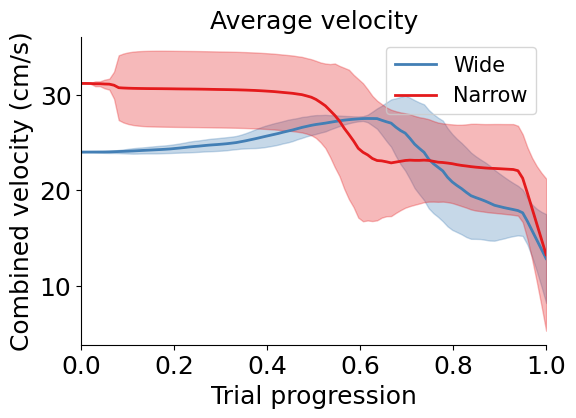

In [16]:
def compute_velocity(positions_x, positions_y, dt=.1):
    """Compute velocity from position data"""
    # Scale to cm: x from [0,59] to [-20,20], y from [0,49] to [-20,20]
    x_cm = (positions_x / 60) * 40 - 20  # maps [0,59] to [-20,20]
    y_cm = (positions_y / 50) * 40 - 20  # maps [0,49] to [-20,20]
    
    dx = np.diff(x_cm)
    dy = np.diff(y_cm)
    velocity = np.sqrt(dx**2 + dy**2) / dt
    return velocity


trials_per_condition=30

# plot narrow 
gap_width=6

port_reward=1
info_matrix=np.load(f'new_info_matrix_hres_{gap_width}.npy')[:,:-10]
mask = np.ones_like(info_matrix)
gradient = np.linspace(0.0, 1., info_matrix.shape[1])
for i in range(info_matrix.shape[1]):
    mask[:, i] = gradient[i]
masked_info_matrix = info_matrix * mask

env = MouseNavigationEnv(
    info_matrix=info_matrix,
    nx=60, ny=50, max_v=4, i_threshold=5, 
    noise=0.3, 
    vcost=0.01, 
    wcost=0.01, 
    timecost=0.001, 
    info_scale=0.3,
    max_steps=200, 
    reward_magnitude=3
)

model_path = f"./mouse_navigation_modelw{gap_width}"
print(f"Model laoded with {model_path}")
model = PPO.load(model_path)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    left_trial_positions_x = []
    left_trial_positions_y = []
    left_trial_info_values = []
    left_trial_results = []
    left_trial_rewards = []
    left_trial_final_info = []
    
    right_trial_positions_x = []
    right_trial_positions_y = []
    right_trial_info_values = []
    right_trial_results = []
    right_trial_rewards = []
    right_trial_final_info = []
    
    # Run multiple left port trials
    for trial in range(trials_per_condition):
        obs, _ = env.reset(options=0)
        done = False

        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        left_trial_positions_x.append(positions_x)
        left_trial_positions_y.append(positions_y)
        left_trial_info_values.append(info_values)
        left_trial_rewards.append(total_reward)
        left_trial_final_info.append(info)
        
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        left_trial_results.append(result)
    
    # Run multiple right port trials
    for trial in range(trials_per_condition):
        obs, _ = env.reset(options=59)
        done = False

        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        right_trial_positions_x.append(positions_x)
        right_trial_positions_y.append(positions_y)
        right_trial_info_values.append(info_values)
        right_trial_rewards.append(total_reward)
        right_trial_final_info.append(info)
        
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        right_trial_results.append(result)

# Compute velocities for narrow gap
left_vel_narrow = []
for x, y in zip(left_trial_positions_x, left_trial_positions_y):
    vel = compute_velocity(x, y)
    if len(vel) > 1:
        progress = np.linspace(0, 1, len(vel))
        common_progress = np.linspace(0, 1, 100)
        interp_vel = np.interp(common_progress, progress, vel)
        left_vel_narrow.append(interp_vel)

right_vel_narrow = []
for x, y in zip(right_trial_positions_x, right_trial_positions_y):
    vel = compute_velocity(x, y)
    if len(vel) > 1:
        progress = np.linspace(0, 1, len(vel))
        common_progress = np.linspace(0, 1, 100)
        interp_vel = np.interp(common_progress, progress, vel)
        right_vel_narrow.append(interp_vel)

left_vel_narrow_array = np.array(left_vel_narrow)
right_vel_narrow_array = np.array(right_vel_narrow)
combined_vel_narrow = np.concatenate([left_vel_narrow_array, right_vel_narrow_array])
narrow_mean = np.mean(combined_vel_narrow, axis=0)
narrow_std = np.std(combined_vel_narrow, axis=0)

# plot wide
gap_width=13

port_reward=1
info_matrix=np.load(f'new_info_matrix_hres_{gap_width}.npy')[:,:-10]
mask = np.ones_like(info_matrix)
gradient = np.linspace(0.0, 1., info_matrix.shape[1])
for i in range(info_matrix.shape[1]):
    mask[:, i] = gradient[i]
masked_info_matrix = info_matrix * mask

env = MouseNavigationEnv(
    info_matrix=info_matrix,
    nx=60, ny=50, max_v=4, i_threshold=5, 
    noise=0.3, 
    vcost=0.01, 
    wcost=0.01, 
    timecost=0.001, 
    info_scale=0.3,
    max_steps=200, 
    reward_magnitude=3
)

model_path = f"./mouse_navigation_modelw{gap_width}"
print(f"Model laoded with {model_path}")
model = PPO.load(model_path)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    left_trial_positions_x = []
    left_trial_positions_y = []
    left_trial_info_values = []
    left_trial_results = []
    left_trial_rewards = []
    left_trial_final_info = []
    
    right_trial_positions_x = []
    right_trial_positions_y = []
    right_trial_info_values = []
    right_trial_results = []
    right_trial_rewards = []
    right_trial_final_info = []
    
    # Run multiple left port trials
    for trial in range(trials_per_condition):
        obs, _ = env.reset(options=0)
        done = False

        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        left_trial_positions_x.append(positions_x)
        left_trial_positions_y.append(positions_y)
        left_trial_info_values.append(info_values)
        left_trial_rewards.append(total_reward)
        left_trial_final_info.append(info)
        
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        left_trial_results.append(result)
    
    # Run multiple right port trials
    for trial in range(trials_per_condition):
        obs, _ = env.reset(options=59)
        done = False

        positions_x = []
        positions_y = []
        info_values = []
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            
            positions_x.append(info['position'][0])
            positions_y.append(info['position'][1])
            info_values.append(info['cumulative_info'])
        
        positions_x = np.array(positions_x)
        positions_y = np.array(positions_y)
        
        right_trial_positions_x.append(positions_x)
        right_trial_positions_y.append(positions_y)
        right_trial_info_values.append(info_values)
        right_trial_rewards.append(total_reward)
        right_trial_final_info.append(info)
        
        result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
        if info['chosen_port'] is None:
            result = "Timeout/Stopped"
        right_trial_results.append(result)

# Compute velocities for wide gap
left_vel_wide = []
for x, y in zip(left_trial_positions_x, left_trial_positions_y):
    vel = compute_velocity(x, y)
    if len(vel) > 1:
        progress = np.linspace(0, 1, len(vel))
        common_progress = np.linspace(0, 1, 100)
        interp_vel = np.interp(common_progress, progress, vel)
        left_vel_wide.append(interp_vel)

right_vel_wide = []
for x, y in zip(right_trial_positions_x, right_trial_positions_y):
    vel = compute_velocity(x, y)
    if len(vel) > 1:
        progress = np.linspace(0, 1, len(vel))
        common_progress = np.linspace(0, 1, 100)
        interp_vel = np.interp(common_progress, progress, vel)
        right_vel_wide.append(interp_vel)

left_vel_wide_array = np.array(left_vel_wide)
right_vel_wide_array = np.array(right_vel_wide)
combined_vel_wide = np.concatenate([left_vel_wide_array, right_vel_wide_array])
wide_mean = np.mean(combined_vel_wide, axis=0)
wide_std = np.std(combined_vel_wide, axis=0)

# Plot velocity
plt.figure(figsize=(6, 4))

progress = np.linspace(0, 1, len(narrow_mean))

plt.plot(progress, wide_mean, color=colors_aperture[1], linewidth=2, label='Wide')
plt.plot(progress, narrow_mean, color=colors_aperture[0], linewidth=2, label='Narrow')

plt.fill_between(progress, 
                wide_mean - wide_std, 
                wide_mean + wide_std, 
                alpha=0.3, color=colors_aperture[1])
plt.fill_between(progress, 
                narrow_mean - narrow_std, 
                narrow_mean + narrow_std, 
                alpha=0.3, color=colors_aperture[0])

plt.xlabel('Trial progression')
plt.ylabel('Combined velocity (cm/s)')
plt.title('Average velocity')
plt.legend()
plt.xlim(0, 1)

plt.savefig("average velocity.svg", format='svg', bbox_inches='tight')


plt.show()